# 20210808053 Data Mining Final Project

**Project:** Computer Science Journal Finder and Topic Clustering  
**Student:** Umut Altun
**Student No:** 20210808053  
**GitHub:** https://github.com/walterbishop67/data_mining_hw2.git

This notebook is the Jupyter deliverable for the course final project. It demonstrates that the submitted software satisfies the assignment requirements: a journal finder for computer science articles, a Top-5 recommendation workflow from an entered abstract, and topic clustering for subject areas.

## 1. Assignment Requirement Checklist

| Requirement from specification | Implemented in this project |
|---|---|
| Source codes with GitHub link | `src/`, `app.py`, `main.py`, GitHub link above |
| Jupyter Notebook format | This notebook: `notebooks/20210808053_Final_Project.ipynb` |
| IEEE conference report with literature review | `report/20210808053_IEEE_PROJECT_REPORT.tex` |
| Journal finder software tailored to CS | Streamlit app launched with `python main.py` |
| User enters article abstract | Journal Recommender tab has an abstract input |
| Program lists Top-5 relevant journals | Saved final classifier returns the top 5 journals |
| Generate clusters of topics | KMeans topic clusters are shown in the Topic Clusters tab |

The report contains the literature review and methodological discussion. This notebook focuses on reproducible project evidence and executable checks.

## 2. Method Summary

The project uses the relational publication database tables requested in the assignment: `AcademicRecord`, `AcademicRecordAbstract`, `Publication`, `AcademicRecordKeyword`, `AcademicRecordKeywordPlus`, and `AcademicRecordSubject`.

The final recommendation model is a content-based supervised classifier:

1. Build enriched article records from SQLite.
2. Clean title, abstract, keywords, Keyword Plus, and subject fields.
3. Use separate TF-IDF vectorizers for four channels: title, abstract, keywords, and subjects.
4. Combine channels with `ColumnTransformer`.
5. Train `SGDClassifier(loss="log_loss")` for multi-class journal prediction.
6. Return the five journals with highest predicted probability.

Topic clustering is unsupervised: rich article text is vectorized with TF-IDF and clustered with KMeans.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_dataset, summarize_dataset
from src.final_project.clustering import infer_cluster_name, load_clustered_data, summarize_cluster
from src.final_project.paths import (
    CLUSTERED_DATASET_PATH,
    DB_PATH,
    PIPELINE_PATH,
    RECOMMENDER_META_PATH,
)
from src.final_project.recommender_model import load_pipeline, recommend_journals

ROOT = Path.cwd()
print('Project root:', ROOT)
print('SQLite database exists:', DB_PATH.is_file(), DB_PATH)
print('Saved recommender exists:', PIPELINE_PATH.is_file(), PIPELINE_PATH)
print('Saved cluster CSV exists:', CLUSTERED_DATASET_PATH.is_file(), CLUSTERED_DATASET_PATH)

Project root: C:\Users\umut3\Downloads\DATA_MINING
SQLite database exists: True C:\Users\umut3\Downloads\DATA_MINING\CompSciencePub.sqlite
Saved recommender exists: True C:\Users\umut3\Downloads\DATA_MINING\exports\20210808053\journal_recommender_pipeline.pkl
Saved cluster CSV exists: True C:\Users\umut3\Downloads\DATA_MINING\exports\20210808053\step9_clustered_dataset.csv


## 3. Dataset Verification

The following cell loads the usable article records from `CompSciencePub.sqlite` using the same loader used by tests and baseline modules. The final classifier uses an enriched derivative of this data.

In [2]:
frame = load_dataset(DB_PATH)
summary = summarize_dataset(frame)
display(pd.Series(summary, name='count'))

preview_columns = ['record_id', 'title', 'journal', 'subjects']
display(frame[preview_columns].head(5))

articles    23061
journals      455
subjects       80
Name: count, dtype: int64

,record_id,title,journal,subjects
0,88652,An updated survey of GA-based multiobjective o...,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods, Computer S..."
1,88653,The state of the art in distributed query proc...,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods, Computer S..."
2,88654,Logical models of argument,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods, Computer S..."
3,88655,Information retrieval on the Web,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods, Computer S..."
4,88656,A guided tour to approximate string matching,ACM COMPUTING SURVEYS,"Computer Science, Theory & Methods, Computer S..."


## 4. Train/Test Separation and Saved Metrics

The final saved model uses a stratified train/test split. The holdout test set is kept separate for evaluation. The serialized Streamlit model is fit only on the training split, so test records are not reused during final model serialization.

In [3]:
meta = json.loads(RECOMMENDER_META_PATH.read_text(encoding='utf-8-sig'))
important_metrics = {
    'Articles used': meta['n_articles'],
    'Journal classes': meta['n_journals'],
    'Split strategy': meta['split_strategy'],
    'Saved model fit scope': meta['saved_model_fit_scope'],
    'Train samples': meta['train_n_samples'],
    'Test samples': meta['test_n_samples'],
    'Train Top-1': round(meta['train_top1_accuracy'], 4),
    'Train Top-5': round(meta['train_top5_accuracy'], 4),
    'Holdout Top-1': round(meta['holdout_top1_accuracy'], 4),
    'Holdout Top-5': round(meta['holdout_top5_accuracy'], 4),
}
display(pd.Series(important_metrics, name='value'))

Articles used                                  22966
Journal classes                                  406
Split strategy           stratified_train_test_split
Saved model fit scope               train_split_only
Train samples                                  18372
Test samples                                    4594
Train Top-1                                   0.9994
Train Top-5                                      1.0
Holdout Top-1                                 0.7061
Holdout Top-5                                 0.9323
Name: value, dtype: object

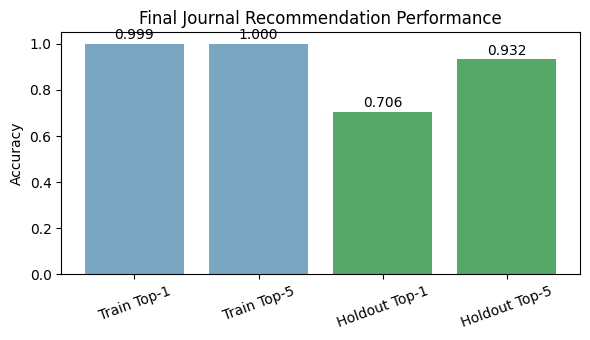

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
labels = ['Train Top-1', 'Train Top-5', 'Holdout Top-1', 'Holdout Top-5']
values = [
    meta['train_top1_accuracy'],
    meta['train_top5_accuracy'],
    meta['holdout_top1_accuracy'],
    meta['holdout_top5_accuracy'],
]
colors = ['#7aa6c2', '#7aa6c2', '#55a868', '#55a868']
ax.bar(labels, values, color=colors)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Final Journal Recommendation Performance')
ax.tick_params(axis='x', rotation=20)
for idx, value in enumerate(values):
    ax.text(idx, value + 0.02, f'{value:.3f}', ha='center')
plt.tight_layout()
plt.show()

## 5. Top-5 Journal Recommendation Demo

This is the core requirement of the assignment: when an author enters an article abstract, the program lists the five most relevant journals. The same saved pipeline is used by the Streamlit interface.

In [5]:
pipeline = load_pipeline()
print('Loaded journal classes:', len(pipeline.classes_))

sample_abstract = '''
This paper proposes a graph neural network model for mining software repository data and predicting source code defects.
The experiments evaluate precision, recall, and generalization on open source software projects using source code metrics and commit history.
'''

recommendations = recommend_journals(
    pipeline,
    abstract=sample_abstract,
    title='Graph neural networks for software defect prediction',
    keywords='software mining, defect prediction, graph neural networks',
    subjects='Artificial Intelligence, Software Engineering',
    top_k=5,
)
display(recommendations)

Loaded journal classes: 406


,rank,journal,score
0,1,INTERNATIONAL JOURNAL OF SOFTWARE ENGINEERING ...,0.0809
1,2,JOURNAL OF WEB SEMANTICS,0.0636
2,3,IEEE TRANSACTIONS ON COMPUTATIONAL INTELLIGENC...,0.0495
3,4,INFORMATION AND SOFTWARE TECHNOLOGY,0.0469
4,5,AUTOMATED SOFTWARE ENGINEERING,0.0359


## 6. Topic Clustering Evidence

The assignment also asks for clusters of topics for subject areas. The saved KMeans output assigns each article to a topic cluster and the dashboard summarizes clusters by representative terms and dominant journals.

In [6]:
clusters = load_clustered_data()
cluster_counts = clusters['cluster'].value_counts().sort_index().rename('article_count').to_frame()
cluster_counts['cluster_name'] = [infer_cluster_name(cluster_id) for cluster_id in cluster_counts.index]
print('Clustered article rows:', len(clusters))
print('Number of clusters:', clusters['cluster'].nunique())
display(cluster_counts)

Clustered article rows: 22980
Number of clusters: 10


,article_count,cluster_name
cluster,,
0,996,Cloud Computing and Web Services
1,8596,"General CS, Formal Methods and Systems"
2,2907,Computer Vision and Neural Learning
3,1352,"Data Mining, Databases and Knowledge Discovery"
4,1418,Optimization and Evolutionary Computation
5,3218,Information Systems and Human-Centered Computing
6,752,Bioinformatics and Computational Biology
7,2365,Communication Networks and Telecommunications
8,669,Fuzzy Logic and Decision Making


In [7]:
selected_cluster = int(cluster_counts['article_count'].idxmax())
cluster_summary = summarize_cluster(clusters, selected_cluster)
print('Selected cluster:', selected_cluster)
print('Cluster name:', cluster_summary['name'])
print('Article count:', cluster_summary['article_count'])
print('Representative terms:', ', '.join(cluster_summary['keywords']))

print('Top journals in selected cluster:')
display(cluster_summary['top_journals'].head(10))

print('Sample articles in selected cluster:')
display(cluster_summary['sample_articles'].head(10))

Selected cluster: 1
Cluster name: General CS, Formal Methods and Systems
Article count: 8596
Representative terms: software, systems, theory, methods, model
Top journals in selected cluster:


,JournalName,Count
0,FORMAL METHODS IN SYSTEM DESIGN,75
1,CMES-COMPUTER MODELING IN ENGINEERING & SCIENCES,74
2,COMPUTERS & FLUIDS,74
3,ACM TRANSACTIONS ON PROGRAMMING LANGUAGES AND ...,73
4,JOURNAL OF CRYPTOLOGY,73
5,ACTA INFORMATICA,73
6,DESIGNS CODES AND CRYPTOGRAPHY,73
7,INFORMATION AND COMPUTATION,72
8,MATHEMATICAL AND COMPUTER MODELLING OF DYNAMIC...,71
9,ACM TRANSACTIONS ON DESIGN AUTOMATION OF ELECT...,71


Sample articles in selected cluster:


,AcademicRecordID,JournalName
2,88654,ACM COMPUTING SURVEYS
4,88656,ACM COMPUTING SURVEYS
5,88657,ACM COMPUTING SURVEYS
7,88659,ACM COMPUTING SURVEYS
9,88661,ACM COMPUTING SURVEYS
10,88662,ACM COMPUTING SURVEYS
14,88666,ACM COMPUTING SURVEYS
15,88667,ACM COMPUTING SURVEYS
16,88668,ACM COMPUTING SURVEYS
18,88670,ACM COMPUTING SURVEYS


## 7. Software Usage

Run Streamlit:

```powershell
python main.py
```

Run this notebook in Jupyter:

```powershell
python main.py --jupyter
```

Run both Streamlit and Jupyter:

```powershell
python main.py --both
```

The Streamlit app has two tabs: `Journal Recommender` and `Topic Clusters`.

## 8. Rebuild Commands

The clean submission keeps only final saved artifacts. Intermediate training CSV files can be regenerated when retraining is needed:

```powershell
python -m src.final_project.enrichment
python -m src.final_project.training
python -m src.final_project.topic_modeling
```

Tests:

```powershell
python -m unittest discover -s tests -v
```

## 9. Conclusion

The project satisfies the required deliverables: source code with GitHub link, Jupyter Notebook, IEEE report with literature review, Top-5 journal recommendation from an abstract, and topic clustering for computer science subject areas. The final holdout Top-5 accuracy is **0.9323**, which directly matches the ranked journal recommendation requirement.